In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Metrics
from sklearn.metrics import r2_score, mean_squared_error


In [3]:
df = pd.read_csv("/content/paddy+dataset.zip")

df.head()
df.info()
df.shape

FileNotFoundError: [Errno 2] No such file or directory: '/content/paddy+dataset.zip'

In [ ]:
df.drop_duplicates(inplace=True)

Identify Categorical Columns


In [ ]:
df.select_dtypes(include='object').columns

Index(['Agriblock', 'Variety', 'Soil Types', 'Nursery',
       'Wind Direction_D1_D30', 'Wind Direction_D31_D60',
       'Wind Direction_D61_D90', 'Wind Direction_D91_D120'],
      dtype='object')

Encode them

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [ ]:
target_column = "Paddy yield(in Kg)"
X = df.drop("Paddy yield(in Kg)", axis=1)
y = df["Paddy yield(in Kg)"]

scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


linear Regression


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

Random forest


In [ ]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

Support Vector Machine

In [ ]:
svm = SVR(kernel='rbf')
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

Evaluation Function

In [ ]:
def evaluate(y_true, y_pred, model_name):
    print(f"\n🔹 {model_name}")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

EVALUATE ALL MODELS

In [ ]:
evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, svm_pred, "SVM")



🔹 Linear Regression
R2 Score: 0.9876950807445437
RMSE: 1026.3642617402363

🔹 Random Forest
R2 Score: 0.9890274266094701
RMSE: 969.2066480976354

🔹 SVM
R2 Score: -0.008798731447644315
RMSE: 9293.18111059294


FEATURE IMPORTANCE (Random Forest)

In [ ]:
importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(feat_df.head(10))


Top 10 Important Features:
                      Feature  Importance
4             Seedrate(in Kg)    0.106734
9                  DAP_20days    0.101804
13      Micronutrients_70Days    0.096660
7        Nursery area (Cents)    0.090800
8   LP_nurseryarea(in Tonnes)    0.089754
10        Weed28D_thiobencarb    0.081981
43          Trash(in bundles)    0.078166
12             Potassh_50Days    0.074855
0                   Hectares     0.073872
11                Urea_40Days    0.073667


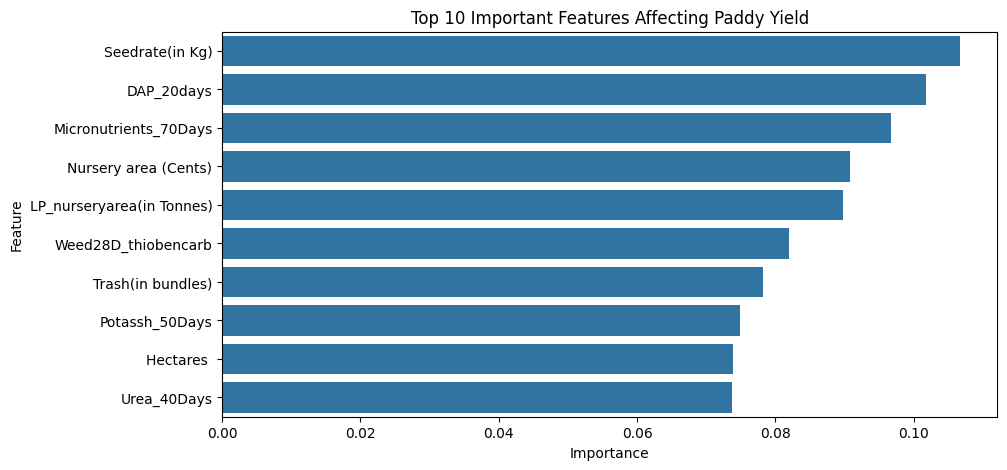

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top 10 Important Features Affecting Paddy Yield")
plt.show()

In [ ]:
def recommend_changes(input_df, model, target):
    print("Running recommendation system...\n")

    current_pred = model.predict(input_df)[0]

    print(f"Predicted Yield: {current_pred:.2f} Kg")
    print(f"Target Yield: {target} Kg\n")

    if current_pred >= target:
        print("Target already achieved!")
        return

    print("Detailed Suggestions:\n")

    temp_df = input_df.copy()

    improvements = [
        "Urea_40Days",
        "DAP_20days",
        "Potassh_50Days",
        "30DAI(in mm)"
    ]

    for col in improvements:
        base_value = temp_df[col][0]
        best_value = base_value
        best_yield = current_pred

        print(f"\n🔧 Adjusting {col}:")

        for factor in [1.1, 1.2, 1.3, 1.5]:
            temp_df[col] = base_value * factor
            new_pred = model.predict(temp_df)[0]

            print(f"{temp_df[col][0]:.2f} → Yield: {new_pred:.2f}")

            if new_pred > best_yield:
                best_yield = new_pred
                best_value = temp_df[col][0]

        if best_value != base_value:
            increase = best_value - base_value
            print(f"   Increase by {increase:.2f} → Best Yield: {best_yield:.2f}")
            current_pred = best_yield
            temp_df[col] = best_value

        if current_pred >= target:
            print("\n🎯 Target achieved!")
            break

    print(f"\n📈 Final Estimated Yield: {current_pred:.2f} Kg")
user_input = get_user_input()
user_input = preprocess_input(user_input)
user_input = align_features(user_input)

target = float(input("Enter target yield (Kg): "))

recommend_changes(user_input, model, target)

NameError: name 'get_user_input' is not defined